### Plotting the Normalised Frequency for ech length in query.bed

Calculating the fragment length and normalising them.

In [1]:
import matplotlib.pyplot as plt
from collections import defaultdict
import random

fragment_counts = defaultdict(int)
total_fragments = 0

with open("query.bed", "r") as f:
    for line in f:
        cols = line.strip().split()
        start = int(cols[1])
        end = int(cols[2])
        length = end - start
        if length > 0:
            fragment_counts[length] += 1
            total_fragments += 1

lengths = sorted(fragment_counts)
normalized_freqs = [fragment_counts[l] / total_fragments for l in lengths]

Plotting the Fragment Length vs. Normalised Frequency.

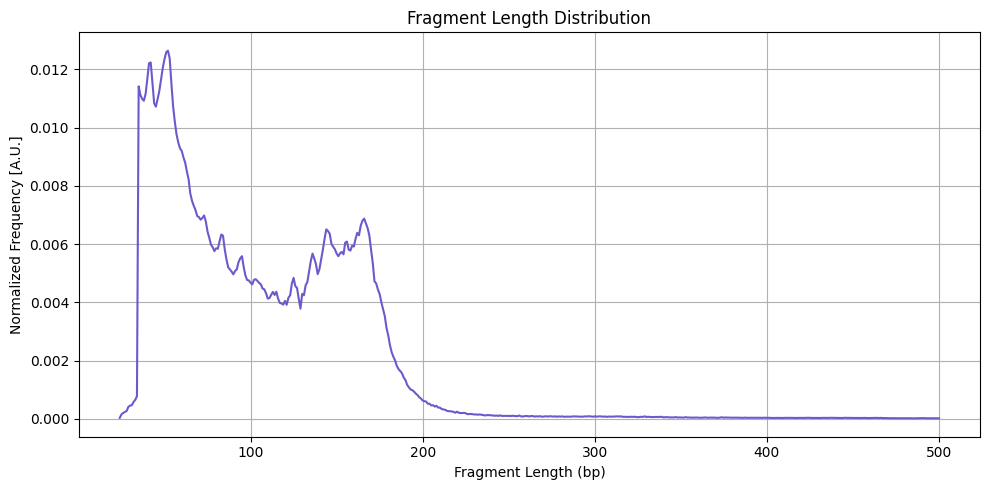

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(lengths, normalized_freqs, color='slateblue')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

### Rescaling of query along the reference.

Loading query.bed and compute raw length distribution.

In [ ]:
fragment_counts = defaultdict(int)
total_fragments = 0

with open("query.bed", "r") as f:
    for line in f:
        cols = line.strip().split()
        start = int(cols[1])
        end = int(cols[2])
        length = end - start
        if length > 0:
            fragment_counts[length] += 1
            total_fragments += 1

Normalising the raw queries.

In [4]:
raw_lengths = sorted(fragment_counts)
raw_freqs = [fragment_counts[l] / total_fragments for l in raw_lengths]

Loading the reference data.

In [5]:
reference_distribution = {}
with open("reference.hist") as ref_file:
    for line in ref_file:
        parts = line.strip().split()
        if len(parts) >= 2:
            length = int(parts[0])
            freq = float(parts[1])
            reference_distribution[length] = freq

total_ref_freq = sum(reference_distribution.values())
normalized_ref = {l: f / total_ref_freq for l, f in reference_distribution.items()}

Plotting the original query vs. reference.

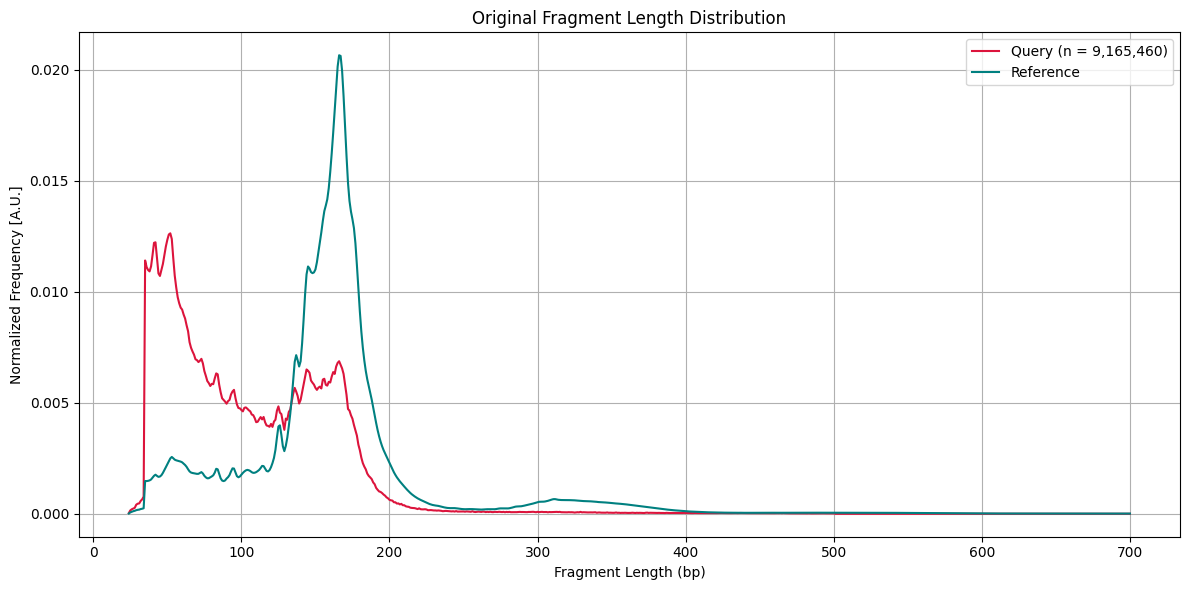

In [6]:
combined_lengths = sorted(set(raw_lengths) | set(normalized_ref.keys()))

plt.figure(figsize=(12, 6))

# Raw query (like expected plot)
plt.plot(combined_lengths, [fragment_counts.get(l, 0) / total_fragments for l in combined_lengths],
         color='crimson', label=f"Query (n = {total_fragments:,})")

# Reference
plt.plot(combined_lengths, [normalized_ref.get(l, 0) for l in combined_lengths],
         color='teal', label="Reference")

plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Original Fragment Length Distribution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()